In [1]:
import sys
sys.path.append('../src')
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms

from dataset import HAM10000Dataset
from models import Lens
from exp_ai import GradCAM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

binary_mode = True 
dataset = HAM10000Dataset(
    metadata_csv="../data/HAM10000_metadata_cleaned.csv",
    img_dir="../data/HAM10000_images",
    transform=transform,
    binary=binary_mode
)

model = Lens(
    resnet_size=18, 
    n_classes=2 if binary_mode else 7,       # bin or 7kl
    n_unfreeze=1,      # u1
    n_linear=2         # l2 
)

if binary_mode:
    weights_path = "../weights/R18_bin_u1_l2_weights_A.pth"
else:
    weights_path = "../weights/R18_7kl_u1_l2_weights_A.pth"
model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
print()

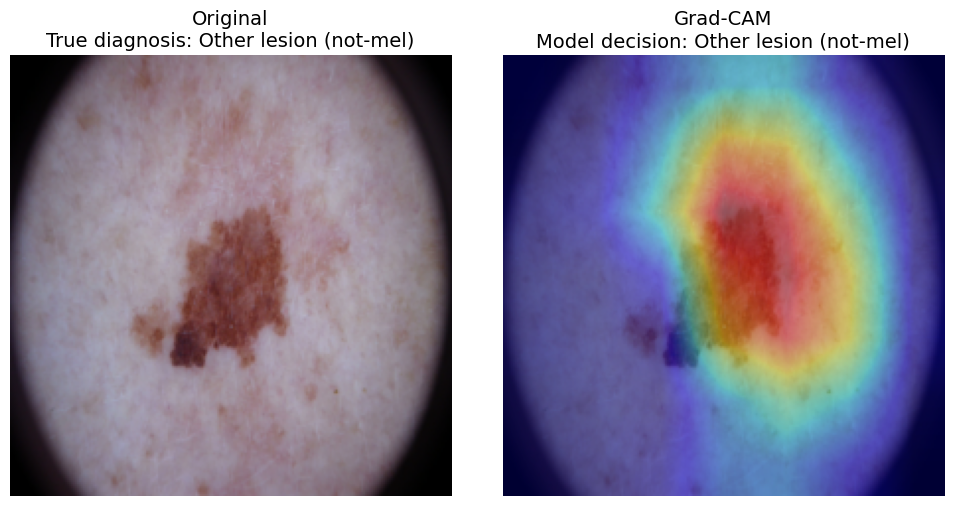

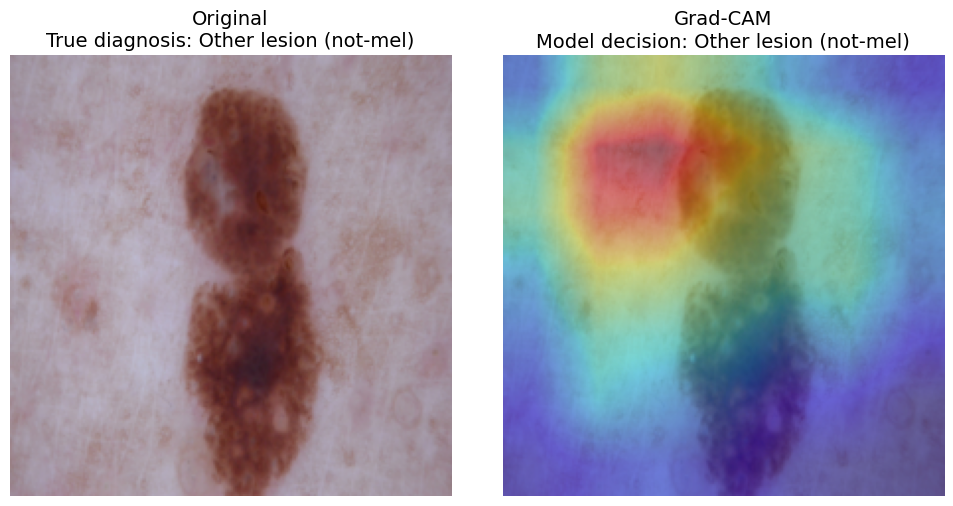

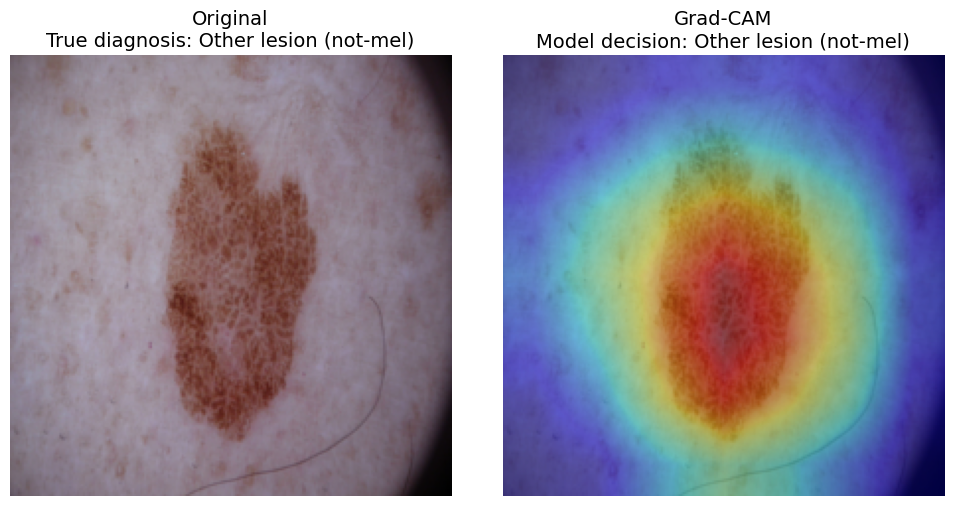

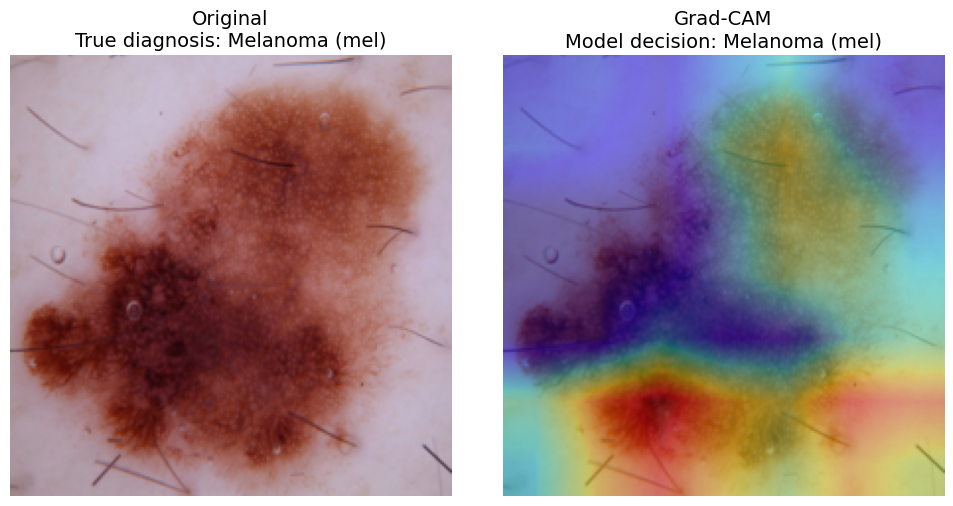

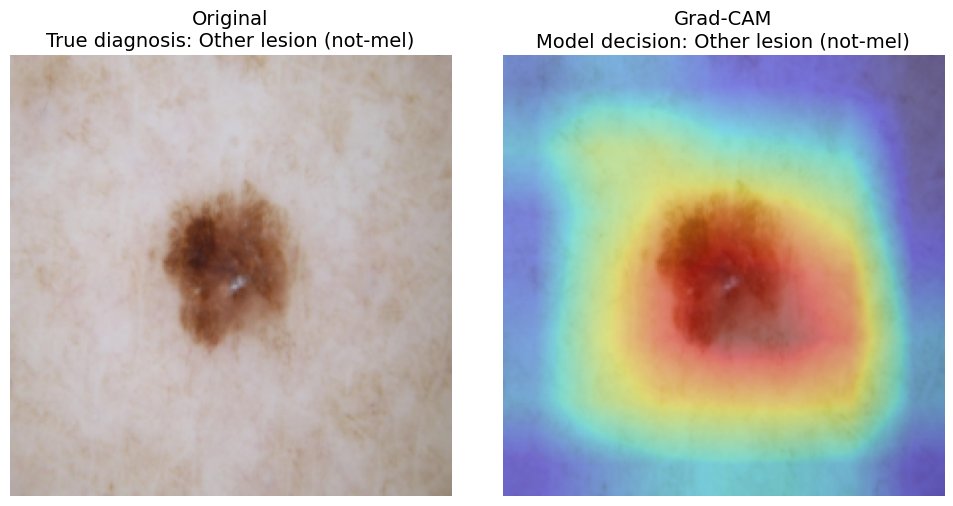

In [3]:
gcam = GradCAM(model)

idxs = [67, 111, 112, 1264, 6703]
for idx in idxs:
    image, _, label = dataset[idx] 
    
    image_batch = image.unsqueeze(0).to(device)
    
    heatmap, pred_idx = gcam.generate(image_batch)
    
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    img_display = inv_normalize(image).permute(1, 2, 0).cpu().numpy()
    img_display = np.clip(img_display, 0, 1)
    
    if binary_mode:
        DISEASES = {
            0: 'Other lesion (not-mel)',
            1: 'Melanoma (mel)'
        }
    else:
        DISEASES = {
            0: 'Actinic Keratosis (akiec)',
            1: 'Basal Cell Carcinoma (bcc)',
            2: 'Benign Keratosis (bkl)',
            3: 'Dermatofibroma (df)',
            4: 'Melanoma (mel)',
            5: 'Melanocytic Nevus (nv)',
            6: 'Vascular Lesion (vasc)'
        }
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    ax[0].imshow(img_display)
    true_name = DISEASES.get(label.item(), "Unknown")
    ax[0].set_title(f"Original\nTrue diagnosis: {true_name}", fontsize=14)
    ax[0].axis('off')
    
    ax[1].imshow(img_display)
    im = ax[1].imshow(heatmap, cmap='jet', alpha=0.4) 
    pred_name = DISEASES.get(pred_idx, "Unknown")
    ax[1].set_title(f"Grad-CAM\nModel decision: {pred_name}", fontsize=14)
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

ERROR FOUND! Index: 80 | Predicted: 1 | True: 0
ERROR FOUND! Index: 91 | Predicted: 1 | True: 0
ERROR FOUND! Index: 93 | Predicted: 1 | True: 0
ERROR FOUND! Index: 122 | Predicted: 1 | True: 0
ERROR FOUND! Index: 126 | Predicted: 1 | True: 0


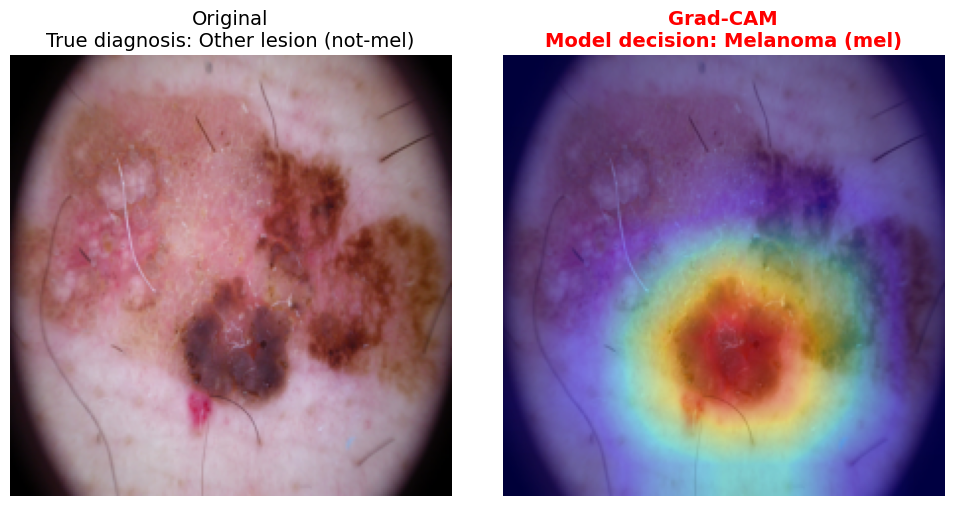

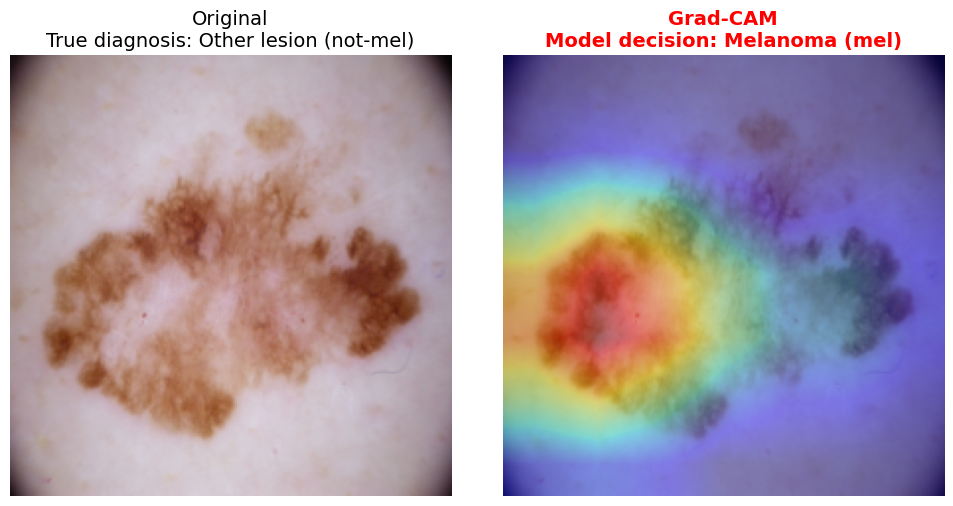

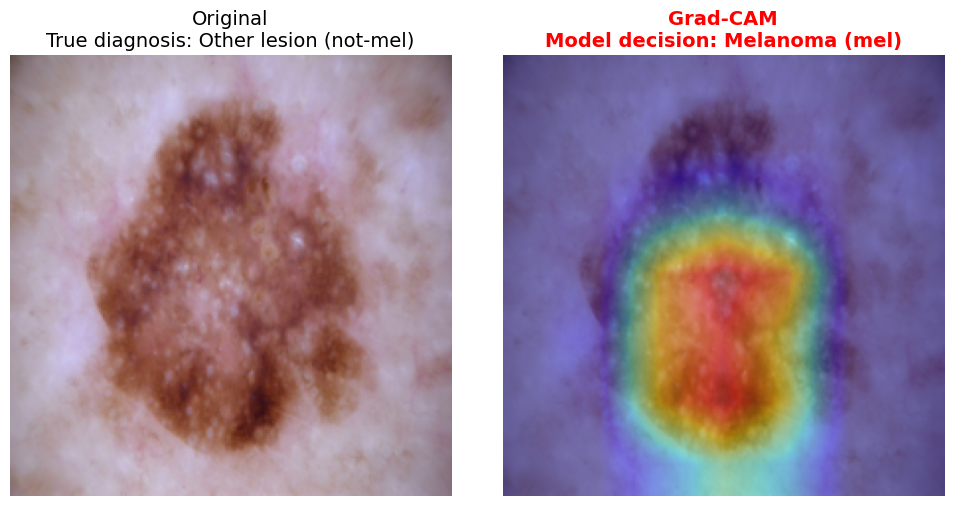

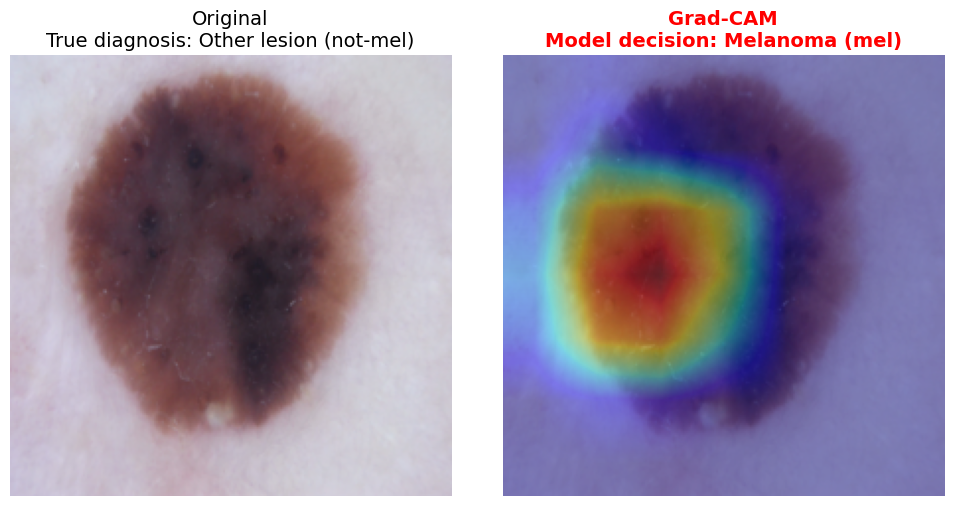

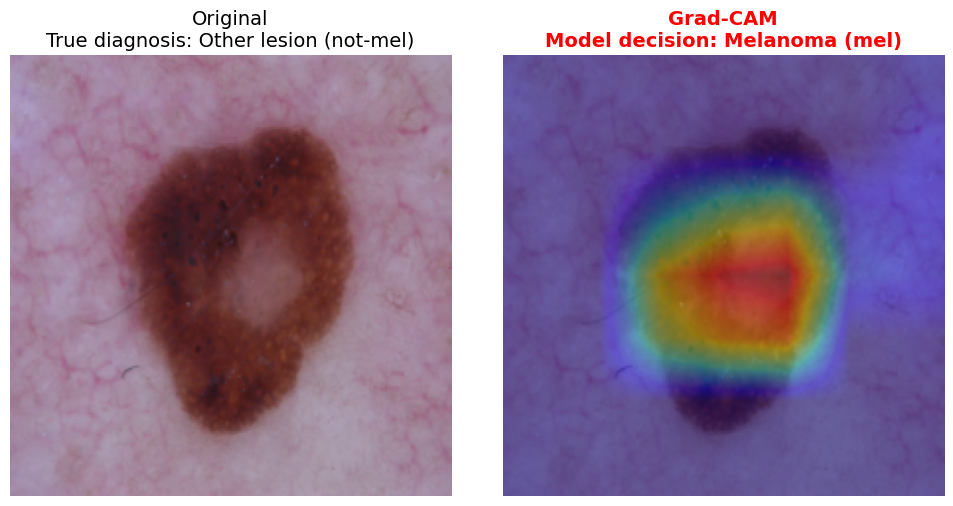

In [4]:
ERRORS_TO_FIND = 5  
found_indices = []
model.eval()

for i in range(len(dataset)):
    try:
        img, _, true_label = dataset[i]
    except FileNotFoundError:
        continue
    
    y_true = true_label.item()
        
    img_batch = img.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_batch)
        y_pred = output.argmax(dim=1).item()
        
    if y_pred != y_true:
        found_indices.append(i)
        print(f"ERROR FOUND! Index: {i} | Predicted: {y_pred} | True: {y_true}")
        
        if len(found_indices) >= ERRORS_TO_FIND:
            break

if len(found_indices) > 0:
    
    for idx in found_indices:
        img, _, true_label = dataset[idx]
        img_batch = img.unsqueeze(0).to(device)
        
        heatmap, pred_idx = gcam.generate(img_batch)
        
        inv_normalize = transforms.Normalize(
            mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
            std=[1/0.229, 1/0.224, 1/0.225]
        )
        img_display = inv_normalize(img).permute(1, 2, 0).cpu().numpy()
        img_display = np.clip(img_display, 0, 1)

        fig, ax = plt.subplots(1, 2, figsize=(10, 5))

        ax[0].imshow(img_display)
        true_name = DISEASES.get(true_label.item(), "Unknown")
        ax[0].set_title(f"Original\nTrue diagnosis: {true_name}", fontsize=14)
        ax[0].axis('off')

        ax[1].imshow(img_display)
        im = ax[1].imshow(heatmap, cmap='jet', alpha=0.4) 
        pred_name = DISEASES.get(pred_idx, "Unknown")
        ax[1].set_title(f"Grad-CAM\nModel decision: {pred_name}", fontsize=14, color='red', fontweight='bold')
        ax[1].axis('off')

        plt.tight_layout()
        plt.show()  
else:
    print("The model did not make any mistakes in the searched pool (or missing images were skipped)!")